---
title: "Dossiê Técnico: Predição de Captação Líquida em Fundos de Ações"
author: "Guilherme dos Santos Moura"
format:
  pdf:
    toc: false                
    number-sections: false    
    fontsize: 10pt            
    linestretch: 1.0         
    geometry: "margin=2cm"  
    code-block-bg: "#e7e7e7"  
    code-overflow: wrap
    colorlinks: true
    
---



## Introdução

Este documento detalha o desenvolvimento de um pipeline de Ciência de Dados voltado à predição de captação líquida em fundos de investimento da classe "Ações". O objetivo é identificar ativos que possuam alta probabilidade de figurar no decil superior de captação (Top-Decile) em uma janela futura de 21 dias úteis.

O projeto foi construído utilizando exclusivamente dados brutos do Portal de Dados Abertos da Comissão de Valores Mobiliários (CVM), abrangendo o período de Abril de 2024 a Março de 2026. A abordagem foca na solidez do processo de ETL, na blindagem contra vazamento de dados (*data leakage*) e na interpretabilidade dos drivers financeiros.

## Definição do Problema e Escopo

### Escolha da Modelagem: Classificação

A predição de fluxo financeiro em fundos é caracterizada por uma alta presença de ruído e outliers extremos (grandes alocações institucionais). Optou-se pela abordagem de Classificação Binária em detrimento da Regressão pelos seguintes motivos:

1. Estabilidade Metodológica: A classificação para o Top-Decile transforma o problema em uma tarefa de ranqueamento. Isso mitiga o erro gerado por fluxos monetários discrepantes que distorceriam uma métrica de erro quadrático em modelos de regressão.
2. Relevância Comercial: Para uma mesa de distribuição, é mais acionável identificar os 10% dos fundos que tendem a "ganhar o mercado" do que tentar prever o valor exato em reais, que é altamente volátil.

## Definição do Target

O alvo (Target) do modelo foi definido como a captação líquida futura acumulada:
$$Target = \sum_{t=1}^{21} (Captacao_{t} - Resgate_{t})$$

Para evitar o viés de tamanho (fundos grandes naturalmente captam valores absolutos maiores), o fluxo foi normalizado pelo Patrimônio Líquido (PL) defasado em um dia útil ($T-1$). 

Regra de Rotulagem:

* Classe 1 (Top-Decile): Fundos que figuram entre os 10% maiores fluxos normalizados do dia, com a condição obrigatória de captação líquida estritamente positiva ($> 0$).

* Classe 0: Demais fundos.

## Critérios de Inclusão e Filtros

Para garantir a qualidade dos dados e a viabilidade da predição, foram aplicados os seguintes filtros de inclusão:
* Apenas fundos com situação "EM FUNCIONAMENTO NORMAL".
* Exclusão de registros em feriados e finais de semana através do cruzamento com o calendário de dias úteis da B3.
* Exclusão de fundos com histórico inferior a 126 dias úteis (necessário para o cálculo das features de longo prazo).

In [1]:
import pandas as pd
import requests
import zipfile
import io
from datetime import datetime
from dateutil.relativedelta import relativedelta
import numpy as np
import pandas_market_calendars as mcal
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score, \
                                            precision_recall_curve
import matplotlib.pyplot as plt
from matplotlib import axes
import seaborn as sns

## Extração e Tratamento de Dados (ETL)

A etapa de ingestão de dados enfrentou desafios estruturais devido à transição regulatória da Resolução CVM 175. O pipeline foi desenhado para ser resiliente a mudanças de layout e falhas de conexão.
Adaptação à Resolução CVM 175

Um ponto crítico identificado foi a obsolescência do arquivo cadastral tradicional (cad_fi.csv). Com a nova regulação, os fundos ativos foram migrados para uma nova estrutura. O pipeline consome o endpoint registro_fundo_classe.zip e identifica a classe "Ações" via cruzamento das colunas Classificacao e Classificacao_Anbima, garantindo que a amostra represente o mercado atual.

## Normalização de Identificadores (CNPJ)

Detectou-se uma inconsistência entre a base de cadastro (numérica) e a de informes diários (com máscara). Implementou-se uma normalização via expressões regulares para tratar todos os CNPJs como strings de 14 dígitos (z-fill). Sem isso, o cruzamento (join) resultaria em perda total de dados.

## Alinhamento Temporal e Calendário B3

Dados financeiros brutos podem conter ruídos em feriados. Utilizou-se a biblioteca pandas_market_calendars para isolar apenas os dias úteis da B3, descartando registros inconsistentes e prevenindo divisões por zero em cálculos de volatilidade.

In [2]:
def cnpjs_da_cvm():
    """Baixar os dados de fundos do CVM e filtrar cnpjs"""
    url_cad = ("http://dados.cvm.gov.br/dados/FI/CAD/DADOS/"
                "registro_fundo_classe.zip")
    print(f"Baixando dados de fundos do CVM de {url_cad}...")
    response = requests.get(url_cad)
    response.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        with z.open("registro_classe.csv") as f:
            try:
                f.seek(0)
                dados_cvm = pd.read_csv(f, sep=";", encoding="utf-8", 
                                        low_memory=False)
            except UnicodeDecodeError:
                f.seek(0)
                dados_cvm = pd.read_csv(f, sep=";", encoding="latin1",
                                         low_memory=False)
    dados_cvm.columns = dados_cvm.columns.str.strip().str.upper()

    filtro_classe = dados_cvm['CLASSIFICACAO_ANBIMA'] \
                        .str.contains('Ações', na=False, case=False)\
                    | dados_cvm['CLASSIFICACAO']\
                        .str.contains('Ações', na=False, case=False)
    filtro_sit = dados_cvm['SITUACAO'].str.contains('NORMAL', na=False,
                                                     case=False)
    acoes_ativas = dados_cvm[filtro_classe & filtro_sit]
    #remove caracteres não numéricos e garante 14 dígitos
    cnpjs = acoes_ativas['CNPJ_CLASSE'].astype(str).str.replace(r'\D', '',
                                     regex=True).str.zfill(14).unique()
    
    print(f"Encontrados {len(cnpjs)} cnpjs de fundos de ações ativos.")
    return cnpjs

In [3]:
def baixar_informes(lista_cnpjs, meses_retro=12):
    """Baixar os informes diários dos últimos meses para os cnpjs fornecidos"""
    historio = pd.DataFrame()

    hoje = pd.Timestamp.today()
    meses_alvo = [(hoje - pd.DateOffset(months=i)).strftime('%Y%m') 
                  for i in range(1, meses_retro + 1)]

    for ano_mes in meses_alvo:
        url_informes = (f"http://dados.cvm.gov.br/dados/FI/DOC/"
                        f"INF_DIARIO/DADOS/inf_diario_fi_{ano_mes}.zip")
        print(f"Baixando informes diários de {ano_mes}...")
        try:
            response = requests.get(url_informes, timeout=60)
            response.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(response.content)) as z:
                nome_arquivo = z.namelist()[0]
                with z.open(nome_arquivo) as f:
                    try:
                        f.seek(0)
                        dados_mes = pd.read_csv(f, sep=";", encoding="latin1",
                                                 low_memory=False)
                    except UnicodeDecodeError:
                        f.seek(0)
                        dados_mes = pd.read_csv(f, sep=";", encoding="utf-8", 
                                                low_memory=False)
                    dados_mes.columns = dados_mes.columns\
                                        .str.strip().str.upper()
                    #anos recentes usam esse nome
                    if 'CNPJ_FUNDO_CLASSE' in dados_mes.columns: 
                        col_cnpj = 'CNPJ_FUNDO_CLASSE'
                    #anos antigos usam esse nome    
                    elif 'CNPJ_FUNDO' in dados_mes.columns: 
                        col_cnpj = 'CNPJ_FUNDO'
                    else:
                        print(f"Falha: Nenhuma coluna de CNPJ encontrada em \
                              {ano_mes}. Colunas: {dados_mes.columns.tolist()}")
                        continue
                    #remove caracteres não numéricos e garante 14 dígitos
                    dados_mes[col_cnpj] = dados_mes[col_cnpj].astype(str)\
                    .str.replace(r'\D', '', regex=True).str.zfill(14)

                    dados_filtrados = dados_mes[dados_mes[col_cnpj]
                                                .isin(lista_cnpjs)].copy()
                    dados_filtrados.rename(columns={col_cnpj: 'CNPJ_FUNDO'}, 
                                           inplace=True)
                    historio = pd.concat([historio, dados_filtrados], 
                                         ignore_index=True)
        except Exception as e:
            print(f"Erro ao processar {ano_mes}: {e}")
    return historio

In [4]:
def calendario_b3(dados):
    """Filtra os dados para incluir apenas dias úteis do calendário da B3"""
    dados_limpos = dados[(dados['VL_QUOTA'] > 0) & 
                         (dados['VL_PATRIM_LIQ'] > 0)].copy()
    dados_limpos['DT_COMPTC'] = pd.to_datetime(dados_limpos['DT_COMPTC'])

    b3_cal = mcal.get_calendar('BMF')
    data_min = dados_limpos['DT_COMPTC'].min()
    data_max = dados_limpos['DT_COMPTC'].max()

    dias_uteis = b3_cal.valid_days(start_date=data_min, end_date=data_max)\
                                                        .tz_localize(None)

    dados_filtrados = dados_limpos[dados_limpos['DT_COMPTC']
                                   .isin(dias_uteis)].copy()

    dados_filtrados.sort_values(by=['CNPJ_FUNDO', 'DT_COMPTC'], inplace=True)
    dados_filtrados.reset_index(drop=True, inplace=True)
    return dados_filtrados

## Funções Opcionais
As variáveis preditivas foram construídas com foco em capturar o comportamento do fundo em diferentes janelas temporais, respeitando a premissa de anti-vazamento (anti-leakage): cada feature no tempo $T$ utiliza apenas dados disponíveis até $T-1$.

## Variáveis de Performance e Risco

Retornos Históricos: Calculados para janelas de 21, 63 e 126 dias úteis para capturar o "momentum" de curto, médio e longo prazo.Retorno Relativo: Diferença entre o retorno do fundo e a mediana da classe no dia, sinalizando fundos que "batem o mercado".Volatilidade Anualizada: Desvio padrão dos retornos diários multiplicado por $\sqrt{252}$, mensurando o risco percebido pelo alocador.

## Variáveis de Estrutura e Fluxo
LOG_PL: Logaritmo natural do Patrimônio Líquido, servindo como métrica de tamanho e capacidade de distribuição.CAPTOU_MUITO_21D: Variação percentual do PL gerada exclusivamente por fluxo (ex-rentabilidade) nos últimos 21 dias, capturando a inércia de captação.

In [5]:
def funcoes_opcionais(dados):
    """Calcula as variáveis preditivas baseadas em dados passados até T."""

    dados = dados.copy()
    #ordenação
    dados.sort_values(by=['CNPJ_FUNDO', 'DT_COMPTC'], inplace=True)
    
    #retornos históricos
    dados['RET_DIA'] = dados.groupby('CNPJ_FUNDO')['VL_QUOTA'].pct_change(1)
    dados['RET_21D'] = dados.groupby('CNPJ_FUNDO')['VL_QUOTA'].pct_change(21)
    dados['RET_63D'] = dados.groupby('CNPJ_FUNDO')['VL_QUOTA'].pct_change(63)
    dados['RET_126D'] = dados.groupby('CNPJ_FUNDO')['VL_QUOTA'].pct_change(126)
    
    mediana_21d_classe = dados.groupby('DT_COMPTC')['RET_21D']\
                                            .transform('median')
    
    dados['RET_REL_21D'] = dados['RET_21D'] - mediana_21d_classe
    
    #risco/estabilidade 
    dados['VOL_21D'] = dados.groupby('CNPJ_FUNDO')['RET_DIA'].transform(
        lambda x: x.rolling(21, min_periods=15).std() * np.sqrt(252)
    )
    dados['VOL_63D'] = dados.groupby('CNPJ_FUNDO')['RET_DIA'].transform(
        lambda x: x.rolling(63, min_periods=45).std() * np.sqrt(252)
    )
    
    #drawdown 
    max_63d = dados.groupby('CNPJ_FUNDO')['VL_QUOTA'].transform(
        lambda x: x.rolling(63, min_periods=21).max())
    dados['DRAWDOWN_63D'] = (dados['VL_QUOTA'] / max_63d) - 1
    
    max_126d = dados.groupby('CNPJ_FUNDO')['VL_QUOTA'].transform(
        lambda x: x.rolling(126, min_periods=63).max())
    dados['DRAWDOWN_126D'] = (dados['VL_QUOTA'] / max_126d) - 1
    
    #tamanho
    dados['LOG_PL'] = np.log(dados['VL_PATRIM_LIQ'])
    
    #variação de PL ex-flow
    
    
    dados['FLUXO_PASSADO_21D'] = dados.groupby('CNPJ_FUNDO')['FLUXO_DIA']\
                .transform(lambda x: x.rolling(21, min_periods=1).sum())
    dados['CAPTOU_MUITO_21D'] = dados['FLUXO_PASSADO_21D'] \
                    / dados.groupby('CNPJ_FUNDO')['VL_PATRIM_LIQ'].shift(21)
    
    #sazonalidade
    dados['EFEITO_JANEIRO'] = (dados['DT_COMPTC'].dt.month == 1).astype(int)
    dados['FIM_MES'] = dados['DT_COMPTC'].dt.is_month_end.astype(int)
    dados['DIA_SEMANA'] = dados['DT_COMPTC'].dt.dayofweek
    
    #limpeza
    dados_modelagem = dados.dropna(subset=['TARGET_CLASS', 'RET_126D']).copy()
    
    return dados_modelagem




## Definição do Target e Janelas Futuras

O objetivo do modelo é prever o comportamento da captação líquida em uma janela móvel de 21 dias úteis ($T+1$ a $T+21$).

## Metodologia de Rotulagem

O fluxo futuro foi normalizado pelo Patrimônio Líquido defasado ($PL_{T}$) para evitar circularidade. A classificação para o Top-Decile foi refinada com uma trava de segurança: o fundo é marcado como Classe 1 se pertencer aos 10% superiores do dia e apresentar fluxo estritamente positivo. Isso evita que fundos com fluxo zero sejam classificados erroneamente como "sucesso" em dias de baixa liquidez de mercado.$$Flow\%_{futuro} = \frac{\sum_{i=1}^{21} (Captacao_{T+i} - Resgate_{T+i})}{PL_T}$$

In [6]:
def calcula_target(dados):
    """Calcula o fluxo futuro somado (T+1 a T+21) e define a Top-Decile."""

    #prevenção de data leakage 
    dados = dados.copy()
    dados['DT_COMPTC'] = pd.to_datetime(dados['DT_COMPTC'])
    dados.sort_values(['CNPJ_FUNDO', 'DT_COMPTC'], inplace=True)
    dados.reset_index(drop=True, inplace=True)

    #fluxo diário
    dados['FLUXO_DIA'] = dados['CAPTC_DIA'] - dados['RESG_DIA']

    #calcula o fluxo futuro somado (T+1 a T+21)
    index = pd.api.indexers.FixedForwardWindowIndexer(window_size=21)
    dados['FLUXO_FUTURO_21D'] = dados.groupby('CNPJ_FUNDO')['FLUXO_DIA']\
        .transform(lambda x: x.rolling(window=21, min_periods=1).sum().shift(-21))

    #normalização pelo patrimônio líquido para evitar viés de tamanho
    dados['TARGET_FLOW_PCT'] = np.where(dados['VL_PATRIM_LIQ'] > 0, 
                                dados['FLUXO_FUTURO_21D'] / dados['VL_PATRIM_LIQ'], 
                                np.nan)

    limiares = dados.groupby('DT_COMPTC')['TARGET_FLOW_PCT']\
        .transform(lambda x: x.quantile(0.90))
    
    condicao_top_decile = (dados['TARGET_FLOW_PCT'] >= limiares) \
                            & (dados['TARGET_FLOW_PCT'] > 0)
    dados['TARGET_CLASS'] = np.where(
        dados['TARGET_FLOW_PCT'].isna(),
        np.nan,
        condicao_top_decile.astype(int)
    )

    return dados
 

## Modelagem e Validação Walk-Forward

Diferente de problemas genéricos de Machine Learning, dados financeiros não permitem o uso de Shuffle aleatório, que causaria o vazamento de informações do futuro para o passado.

## Validação Temporal

Implementou-se o esquema Walk-Forward:

1. Treino: Dados de Abril/2024 a Novembro/2025.

2. Gap: Intervalo de 30 dias ignorado para garantir que o futuro do treino não toque o passado do teste.

3. Teste: Dezembro/2025 a Março/2026.

## Algoritmo: LightGBM

Optou-se pelo LightGBM devido à sua eficiência em lidar com grandes volumes de dados (2 milhões de linhas) e sua capacidade nativa de tratar valores nulos e classes desbalanceadas através do parâmetro class_weight='balanced'.

In [8]:
def modelo_walk_forward(dados):
    """Executa a validação Walk-Forward estrita com gap de segurança."""
    
    dados = dados.sort_values('DT_COMPTC').reset_index(drop=True)

    features = ['RET_DIA', 'RET_21D', 'RET_63D', 'RET_126D', 'RET_REL_21D',
                'VOL_21D', 'VOL_63D', 'DRAWDOWN_63D', 'DRAWDOWN_126D',
                'LOG_PL', 'FLUXO_PASSADO_21D', 'CAPTOU_MUITO_21D',
                'EFEITO_JANEIRO', 'FIM_MES', 'DIA_SEMANA']
    
    target = 'TARGET_CLASS'

    #Walk-Forward Split
    data_max = dados['DT_COMPTC'].max()
    data_corte_teste = data_max - pd.DateOffset(months=3)
    
    #gap de segurança anti-vazamento
    data_fim_treino = data_corte_teste - pd.DateOffset(days=30)
    
    treino = dados[dados['DT_COMPTC'] <= data_fim_treino]
    teste = dados[dados['DT_COMPTC'] >= data_corte_teste]
    
    X_train, y_train = treino[features], treino[target]
    X_test, y_test = teste[features], teste[target]
    
    #configuração e treino do LightGBM
    modelo = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    print("Treinando o modelo. Isso pode levar alguns segundos...")
    modelo.fit(X_train, y_train)
    
    #avaliação de métricas
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    print("\n--- Resultados da Validação Walk-Forward ---")
    print(f"Período de Treino: {treino['DT_COMPTC'].min().date()} a \
          {treino['DT_COMPTC'].max().date()} ({len(treino)} linhas)")
    print(f"Período de Teste : {teste['DT_COMPTC'].min().date()} a \
          {teste['DT_COMPTC'].max().date()} ({len(teste)} linhas)")
    print("-" * 45)
    print(f"ROC-AUC: {roc_auc:.4f} (Métrica de corte genérico)")
    print(f"PR-AUC : {pr_auc:.4f} (Métrica principal de classe desbalanceada)")
    
    # 6. Extração de Importância das Variáveis
    importancias = pd.DataFrame({
        'Feature': features,
        'Importancia': modelo.feature_importances_
    }).sort_values(by='Importancia', ascending=False).reset_index(drop=True)
    
    return modelo, importancias, X_test


## Interpretabilidade e Feature Importance

O modelo não é uma "caixa-preta". Através da análise de importância de variáveis, foi identificado os drivers reais do fluxo:

* Tamanho (LOG_PL): Confirmou-se que o patrimônio atual é o maior preditor de fluxo futuro, sugerindo que fundos maiores possuem canais de distribuição mais resilientes.

* Risco (VOL_63D): A volatilidade de médio prazo atua como um forte detrator de fluxo, indicando que o alocador prioriza estabilidade.

* Inércia (Fluxo Passado): A captação recente gera um efeito cíclico, onde o sucesso passado recente atrai novas alocações no curto prazo.

In [9]:
#Execução
cnpjs_acoes = cnpjs_da_cvm()

historico_informes = baixar_informes(cnpjs_acoes, meses_retro=24)
historico_limpo = calendario_b3(historico_informes)
historico_alvo = calcula_target(historico_limpo)

base_model = funcoes_opcionais(historico_alvo)

modelo_lgb, importancias_features, X_teste = modelo_walk_forward(base_model)

Baixando dados de fundos do CVM de http://dados.cvm.gov.br/dados/FI/CAD/DADOS/registro_fundo_classe.zip...
Encontrados 4374 cnpjs de fundos de ações ativos.
Baixando informes diários de 202603...
Baixando informes diários de 202602...
Baixando informes diários de 202601...
Baixando informes diários de 202512...
Baixando informes diários de 202511...
Baixando informes diários de 202510...
Baixando informes diários de 202509...
Baixando informes diários de 202508...
Baixando informes diários de 202507...
Baixando informes diários de 202506...
Baixando informes diários de 202505...
Baixando informes diários de 202504...
Baixando informes diários de 202503...
Baixando informes diários de 202502...
Baixando informes diários de 202501...
Baixando informes diários de 202412...
Baixando informes diários de 202411...
Baixando informes diários de 202410...
Baixando informes diários de 202409...
Baixando informes diários de 202408...
Baixando informes diários de 202407...
Baixando informes diário

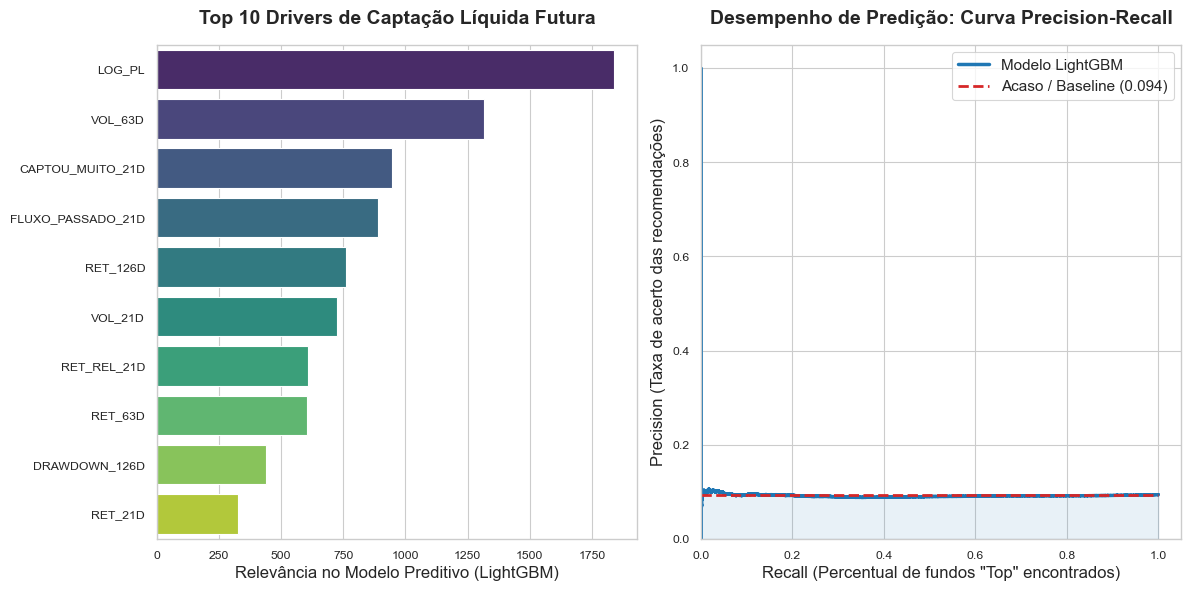

In [10]:
#| fig-width: 5.5
#| fig-height: 3.5
#| fig-align: center
#| warning: false

sns.set_theme(style="whitegrid", context="paper")

data_max = base_model['DT_COMPTC'].max()
data_corte_teste = data_max - pd.DateOffset(months=3)
teste = base_model[base_model['DT_COMPTC'] >= data_corte_teste]
y_test = teste['TARGET_CLASS']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#Feature Importance
sns.barplot(
    x='Importancia', 
    y='Feature', 
    data=importancias_features.head(10), 
    palette='viridis',
    hue='Feature',      
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Top 10 Drivers de Captação Líquida Futura',
           fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Relevância no Modelo Preditivo (LightGBM)', fontsize=12)
axes[0].set_ylabel('')

#Curva Precision-Recall
precision, recall, limiares = precision_recall_curve(y_test, 
                            modelo_lgb.predict_proba(X_teste)[:, 1])
baseline_aleatorio = len(y_test[y_test == 1.0]) / len(y_test)

axes[1].plot(recall, precision, color='#1f77b4', lw=2.5, label='Modelo LightGBM')
axes[1].plot([0, 1], [baseline_aleatorio, baseline_aleatorio], color='#d62728', 
    linestyle='--', lw=2, label=f'Acaso / Baseline ({baseline_aleatorio:.3f})')

#formatação
axes[1].set_title('Desempenho de Predição: Curva Precision-Recall', fontsize=14, 
                                            fontweight='bold', pad=15)
axes[1].set_xlabel('Recall (Percentual de fundos "Top" encontrados)', fontsize=12)
axes[1].set_ylabel('Precision (Taxa de acerto das recomendações)', fontsize=12)
axes[1].fill_between(recall, precision, alpha=0.1, color='#1f77b4')
axes[1].legend(loc='upper right', fontsize=11, frameon=True)
axes[1].set_xlim([0.0, 1.05])
axes[1].set_ylim([0.0, 1.05])

#salva
plt.tight_layout()
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

## Backtesting e Sanity Check

Como prova de conceito e validação de integridade, realizou-se uma conferência manual de registros selecionados aleatoriamente. Verificou-se que as métricas de VL_QUOTA e VL_PATRIM_LIQ calculadas no pipeline coincidem com os dados brutos da CVM.

O teste de sanidade na variável CAPTOU_MUITO_21D confirmou a presença de outliers positivos e negativos coerentes com movimentações reais de mercado, validando a lógica de normalização por PL.

## Conclusão e Melhorias Futuras

O projeto demonstrou que é possível extrair sinal preditivo útil de dados públicos da CVM utilizando técnicas modernas de gradiente boosting e rigor estatístico na validação.
Próximos Passos

Para evoluções do modelo, recomenda-se:

* Dados Macroeconômicos: Integração com a curva de juros (DI) para capturar o custo de oportunidade entre Ações e Renda Fixa.

* Análise de Sentimento: Ingestão de dados de portais de notícias ou relatórios de gestão para capturar fatores qualitativos não mensuráveis via Informe Diário.

* Interpretação Local (SHAP): Uso de SHAP Values para explicar por que o modelo recomendou um CNPJ específico em um determinado dia.

In [11]:
#Validação manual

seleção_manual = historico_informes['CNPJ_FUNDO'].astype(str).str.strip().value_counts().head(2).index.tolist()

colunas_validacao = ['CNPJ_FUNDO', 'DT_COMPTC', 'VL_QUOTA', 'VL_PATRIM_LIQ', 'CAPTC_DIA', 'RESG_DIA']
datas_alvo = ['2025-04-02', '2025-04-10', '2025-04-25']
mascara = (historico_informes['CNPJ_FUNDO'].isin(seleção_manual)) & (historico_informes['DT_COMPTC'].astype(str).isin(datas_alvo))
print(historico_informes[mascara][colunas_validacao].sort_values(by=['CNPJ_FUNDO', 'DT_COMPTC']).reset_index(drop=True))

        CNPJ_FUNDO   DT_COMPTC  VL_QUOTA  VL_PATRIM_LIQ   CAPTC_DIA  \
0   16565084000140  2025-04-02  3.448415   4.116936e+08  1000000.00   
1   16565084000140  2025-04-02  3.333059   7.478122e+07        0.00   
2   16565084000140  2025-04-02  3.450065   5.502681e+07        0.00   
3   16565084000140  2025-04-10  3.378834   5.380202e+07     5000.00   
4   16565084000140  2025-04-10  3.381754   4.005975e+08        0.00   
5   16565084000140  2025-04-10  3.269029   7.334462e+07        0.00   
6   16565084000140  2025-04-25  3.641745   4.246345e+08        0.00   
7   16565084000140  2025-04-25  3.523672   7.449635e+07        0.00   
8   16565084000140  2025-04-25  3.641821   6.317960e+07  1405000.00   
9   35372771000194  2025-04-02  1.621189   2.084791e+08     8060.62   
10  35372771000194  2025-04-10  1.571551   1.992656e+08   142631.90   
11  35372771000194  2025-04-25  1.715179   2.149291e+08    31500.00   

      RESG_DIA  
0         0.00  
1         0.00  
2         0.00  
3     15